# Function 2

<b> Description of the Sample Application:</b> Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks


## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |


## Weekly Progress Log

| Week | Query Submitted (x1-x2) | Output (y) | Acquisition | β (beta) | Kernel | Notes |
|---|---|---|---|---|---|---|
| Week 1 | 0.725451-0.000000 | 0.594526 | UCB | 2.5 | RBF | First submission - exploration-heavy (edge of domain, x2 = 0) |
| Week 2 | 0.959920, 0.959920 | *pending* | UCB | 2.0 (lowered) | RBF | Shifting gradually from exploration toward exploitation, per Week 1 reflection |

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import plot_2d_bo_state, plot_convergence

# Load and Analyse the Data

In [16]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
Y       = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.725451, 0.     ]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([0.5945255267146322]  , dtype=np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X, X_w1_new_point))
Y_updated      = np.append(Y, Y_w1_new_point)

print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553]


In [20]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()
print("Minimum and Maximum Values of Output:\n")
print("Min:", Y.min(), " Max:", Y.max())
print("Best point:", X[np.argmax(Y)], "-> Output =", Y.max())
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (11, 2)
Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]]

Output Shape: (11,)
Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553]

Minimum and Maximum Values of Output:

Min: -0.06562362443733738  Max: 0.6112052157614438
Best point: [0.70263656 0.9265642 ] -> Output = 0.6112052157614438

Data Frame:
          X_1       X_2         Y
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0

# Data Exploration

In [23]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2          Y
count  11.000000  11.000000  11.000000
mean    0.555507   0.443573   0.263751
std     0.231968   0.337557   0.250648
min     0.142699   0.000000  -0.065624
25%     0.389958   0.168918   0.030927
50%     0.577713   0.349005   0.244619
75%     0.714044   0.741547   0.479791
max     0.877791   0.926564   0.611205


In [25]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
Y      0
dtype: int64


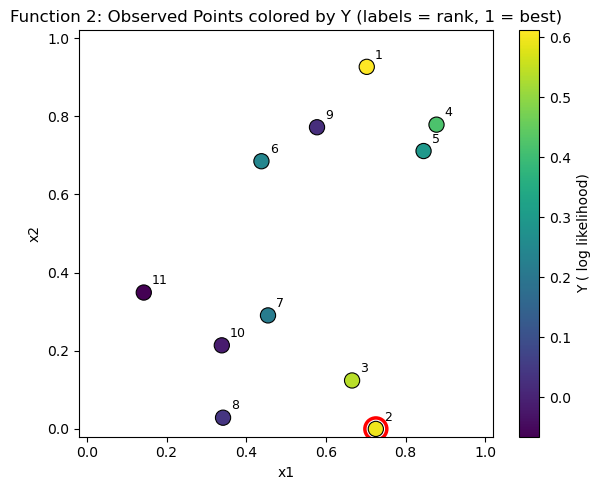

In [37]:
# Scatter Plot
fig, ax   = plt.subplots(figsize = (6,5))
sc        = ax.scatter(X[:,0], X[:,1], c = Y, cmap = 'viridis', s = 120, edgecolor = 'black', linewidth = 0.8)

# Highlighting Week 1 submitted point with a distinct marker
ax.scatter(X_w1_new_point[0], X_w1_new_point[1], facecolor = 'none', edgecolor = 'red', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 1 query')

ranks = (-Y).argsort().argsort() + 1
for i, (px, py) in enumerate(X):
    ax.annotate(str(ranks[i]), (px, py), textcoords = "offset points", xytext=(6, 6), fontsize = 9)
    
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title('Function 2: Observed Points colored by Y (labels = rank, 1 = best)')
fig.colorbar(sc, ax = ax, label = "Y ( log likelihood)")
plt.tight_layout()
plt.show()

**Note:** the Week 1 query landed at x2 = 0.000000 (domain boundary), consistent with the high exploration weight (β = 2.5) used that week. Its output (y = 0.594526) is close to the current best (y = 0.611205 at rank 1), reinforcing that the region around x1 ≈ 0.7–0.9, low-to-mid x2 is promising and worth continued attention alongside the still-unexplored gaps.

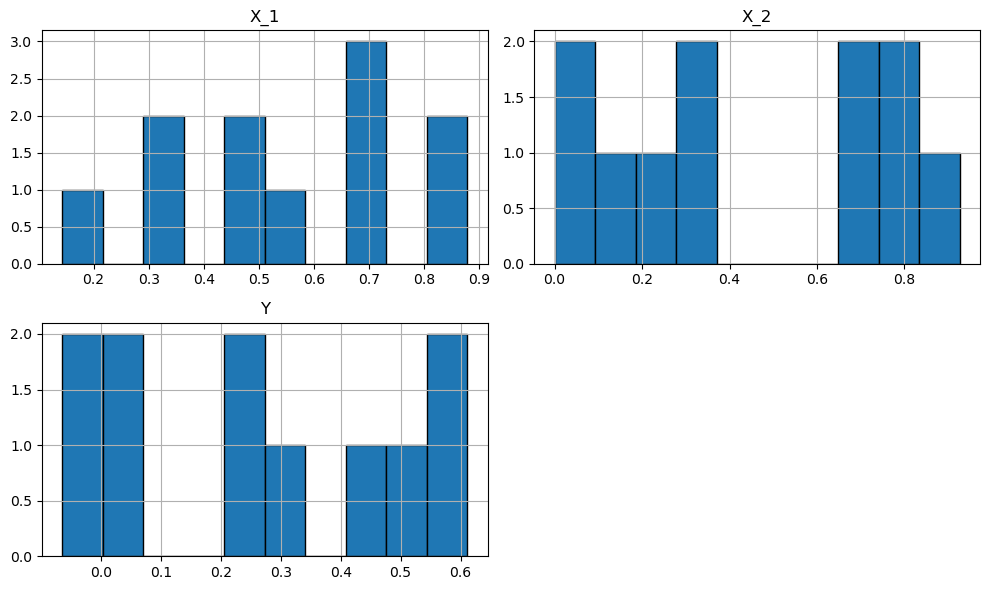

In [41]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'black' )
plt.tight_layout()
plt.show()

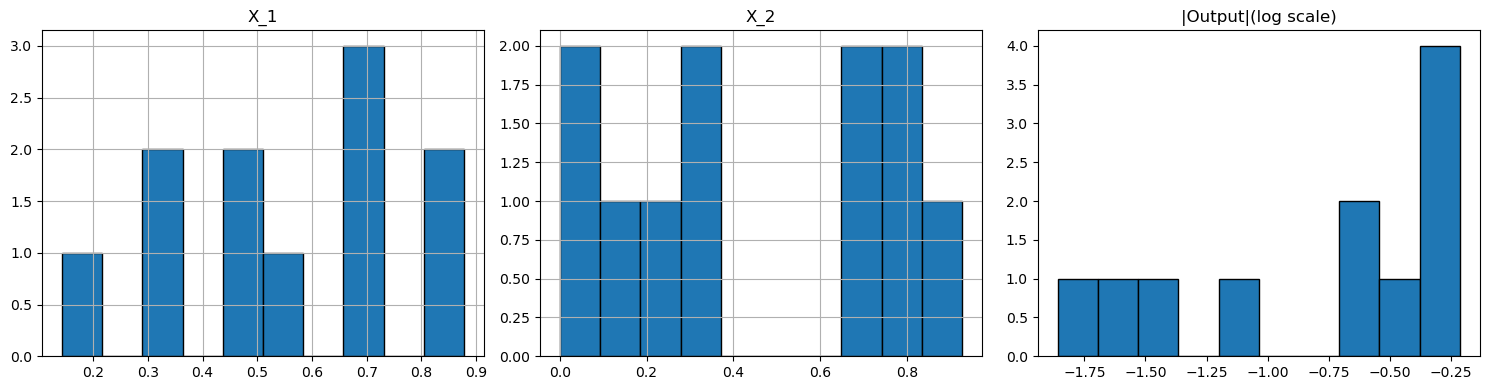

In [43]:
# In the above histogram for the output column, almost every bar seems to be crammed into a single bin near zero, which is not very informative.
# Plotting the column histograms using log scale for Output column
fig, axes = plt.subplots(1,3, figsize = (15,4))

df['X_1'].hist(ax = axes[0], bins = 10, edgecolor = 'black')
axes[0].set_title('X_1')

df['X_2'].hist(ax = axes[1], bins = 10, edgecolor = 'black')
axes[1].set_title('X_2')

magnitude = np.where(Y != 0, np.log10(np.abs(Y) + 1e-300), np.nan)
axes[2].hist(magnitude, bins = 10, edgecolor = 'black')
axes[2].set_title('|Output|(log scale)')


plt.tight_layout()
plt.show()

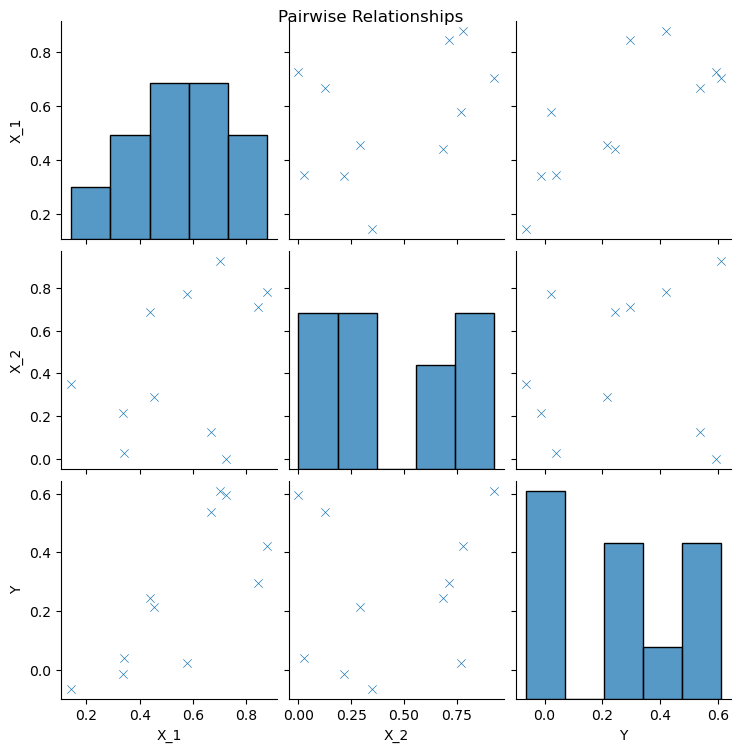

In [44]:
# Understanding the relationships between the variables using a Pair Plot
sns.pairplot(df, kind = 'scatter', diag_kind = 'hist', markers = 'x')
plt.suptitle('Pairwise Relationships', verticalalignment = 'baseline')
plt.show()

# Initialize Gaussian Process

In [48]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [53]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.924**2 * RBF(length_scale=[0.059, 2]) + WhiteKernel(noise_level=0.0125)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- **Week 1:** uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.
- **Week 2:** β is lowered to **2.0**, to shift from exploration toward exploitation.

In [58]:
grid_res   = 500
xs         = np.linspace(0, 1, grid_res)
ys         = np.linspace(0, 1, grid_res)
gx, gy     = np.meshgrid(xs, ys)
candidates = np.column_stack([gx.ravel(), gy.ravel()])

mu, std    = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
#beta       = 2.5    #Week 1 
beta       = 2.0    #Week 2 
ucb        = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.95991984 0.95991984]
Predicted Mean(μ): 3.926325e-01
Predicted Std (σ): 1.940153e-01
UCB Score: 7.806631e-01


# Perform Visualisation ( Week 1 )

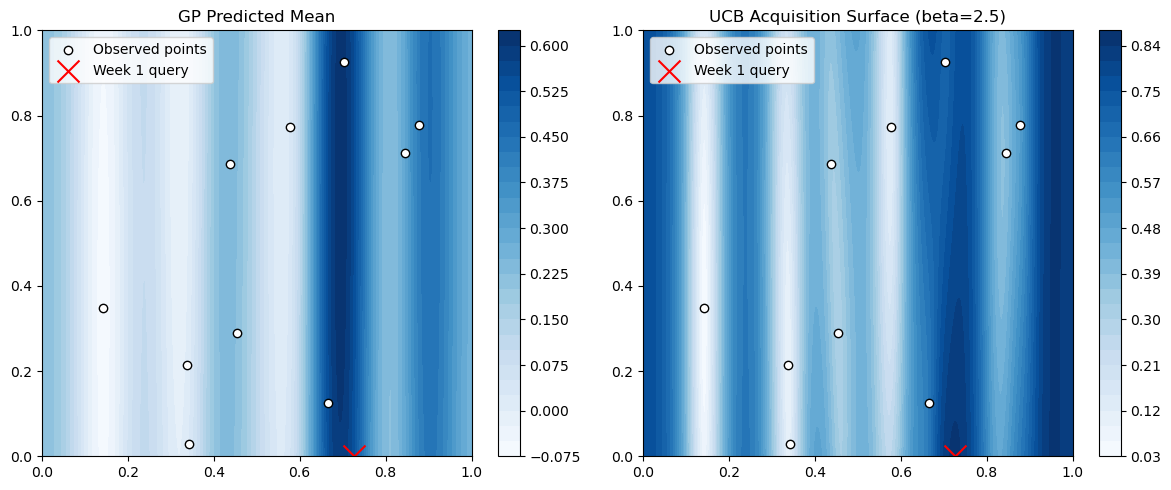

In [49]:
fig, axes  = plt.subplots(1,2, figsize = (12, 5))

# Predicted mean surface
c0 = axes[0].contourf(gx, gy, mu.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[0].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[0].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[0].set_title("GP Predicted Mean")
axes[0].legend(loc = 'upper left')
fig.colorbar(c0, ax=axes[0])

# UCB acquisition surface
c1 = axes[1].contourf(gx, gy, ucb.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[1].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[1].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[1].set_title("UCB Acquisition Surface (beta=2.5)")
axes[1].legend(loc = 'upper left')
fig.colorbar(c1, ax = axes[1])

plt.tight_layout()
plt.show()

# Week 2 Visualisation

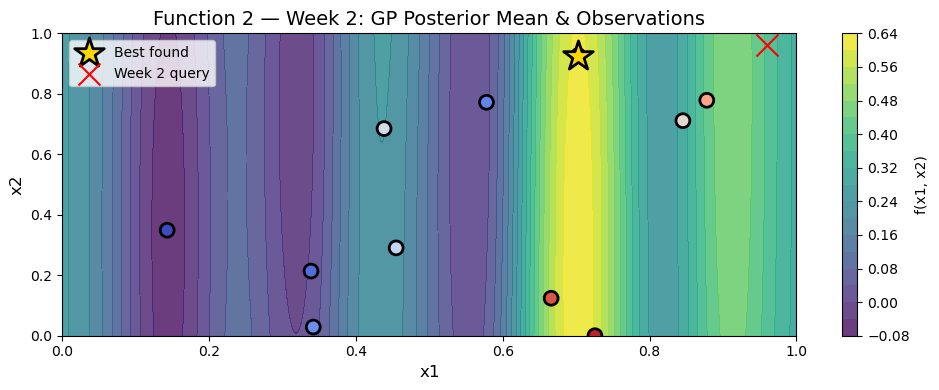

In [66]:
Z_mu = mu.reshape(gx.shape)

fig, ax = plot_2d_bo_state(gx, gy, Z_mu, X, Y, title='Function 2 \u2014 Week 2: GP Posterior Mean & Observations')
ax.scatter(*next_point, c = 'red', marker = 'x', s = 250, label = 'Week 2 query', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Portal Submission 

In [68]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print("Points to be submitted (Week 1):", '0.725451, 0.     ')
print("Points to be submitted (Week 2):", submission_str)
print()

Points to be submitted (Week 1): 0.725451, 0.     
Points to be submitted (Week 2): 0.959920-0.959920



# Plot the Progress of the optimisation process

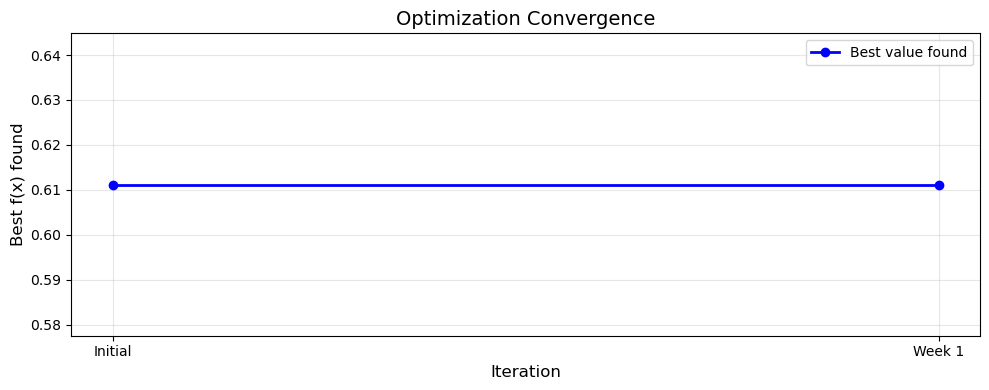

Best value found so far: 0.6112052157614438


In [71]:
# Track best-value-found progress across weeks
best_so_far = [
    0.6112052157614438,  # best after initial 10 points
    max(0.6112052157614438, 0.594525526714632),  # best after Week 1
]

fig, ax     = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(['Initial', 'Week 1'])
plt.show()

print("Best value found so far:", max(best_so_far))